# Determine Copy correction Effects

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.utils import mkdir_safe
from src.chromatin_deconvolution_solver import plot_example_fits
from src.chromatin_deconvolution_solver import plot_branches
from src.chromatin_model import plot_prediction
from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname
from src.RealDataReplication import read_n_fr_b
from src.chromatin_deconvolution_solver import subset_select_highest_G_indices


In [5]:
# Examine an early and late 10kb window on the chromosome, what does the raw data look like?



# Load the replication data for chromosome 4
from pipeline.fit_replication_profiles import main as fit_replication_profile
from src.utils import print_fl
from src.config import load_default_chrom_configs
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.optimize_H import create_bounds_params_from_config

output_directory = 'output/prototype_pipeline_subset/'
chrom = 4
replicate = 1
num_epochs = 1
config = None
np.random.seed(123)

update_params_df, replication_deconvolver, optimizer = fit_replication_profile(chrom=chrom, 
    replicate=replicate, num_epochs=0, output_directory=output_directory, 
    deconvolve_stage=2, save=False)


Deconvolve stage:  2
Loading initial cell cycle parameters from CLOCCS fits.
Shifting mu0, gamma1, and gamma2, for alpha...
Omit windows with less than 75% read coverage.
Running initial iterations...
Warm start config, N, F, and B from directory: output/prototype_pipeline_subset/
Deconvolving 702 regions
Initializing B using timepoint 0
No subset, full parameter updates
** todo: testing learning only delta and lambda **
[0] 00:00:00.354, rn=1.1116836932478817
[1] 00:00:00.705, rn=0.006326133461334883
[2] 00:00:01.058, rn=0.00583422513708287
[3] 00:00:01.413, rn=0.005354293251821002
[4] 00:00:01.768, rn=0.004905544144475561
[5] 00:00:02.120, rn=0.00451598607149126
[6] 00:00:02.472, rn=0.00418615254250576
[7] 00:00:02.825, rn=0.003919207320718416
[8] 00:00:03.178, rn=0.0037091354726334616
[9] 00:00:03.528, rn=0.0035554011271451513
[10] 00:00:03.881, rn=0.0034441310064499313
[11] 00:00:04.243, rn=0.003365601190747188
[12] 00:00:04.596, rn=0.0033147550316953932
[13] 00:00:04.951, rn=0.003

In [242]:
replication_idx = replication_deconvolver.F_df.idxmax(axis=0)
replication_timing_df = pd.DataFrame(replication_idx, columns=['replication_index'])
replication_timing_df = replication_timing_df.sort_values('replication_index')

early_idx = replication_timing_df.iloc[0].name
late_idx = replication_timing_df.iloc[-20].name

In [243]:
predicted_G = replication_deconvolver.N@replication_deconvolver.config.H@\
    replication_deconvolver.F@replication_deconvolver.B
G_df = replication_deconvolver.masked_G_df

In [244]:
predicted_G_df = pd.DataFrame(predicted_G, index=G.index, columns=G.columns)

Text(0.5, 1.0, 'Early')

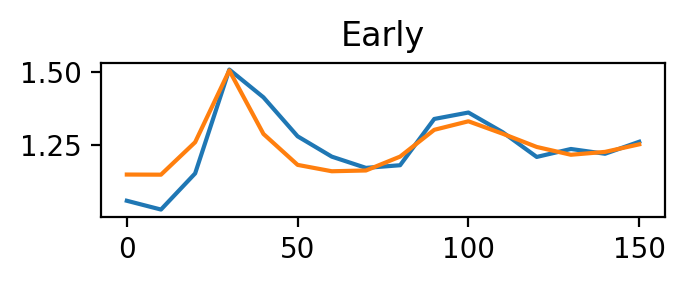

In [332]:
plt.figure(figsize=(8, 1))
plt.subplot(1, 2, 1)
g = G_df[early_idx]
predicted_g = predicted_G_df[early_idx]
plt.plot(g)
plt.plot(predicted_g)
plt.title("Early")

# plt.subplot(1, 2, 2)
# g = G_df[late_idx]
# predicted_g = predicted_G_df[late_idx]
# plt.plot(g)
# plt.plot(predicted_g)
# plt.title("Late")

In [333]:
target_distribution = pd.read_csv(
    'datasets/computed_mnase/target_length_distribution_rep1.csv').set_index('length')
target_distribution

,value
length,
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
246,0.529039
247,0.526956
248,0.523968


In [336]:
from src.chromatin_model import ChromatinModel
from src.CombinedReplicationDeconvolution import load_config_from_replication_runs

config1, config2 = load_config_from_replication_runs('output/prototype_pipeline_subset/', 
    chrom=4)
chromatin_model1 = ChromatinModel(config1)
span = early_idx, early_idx+10000
chromatin_model1.load_mnase_span(chrom=4, mnase_span=span)

Shifting mu0, gamma1, and gamma2, for alpha...
Loading chromosome reads: 4
Applying a normalization for length distribution


In [337]:
exact_bins = chromatin_model1.exact_bins
normalized_1 = exact_bins / exact_bins.mean(axis=1).mean(axis=1)[:, None, None]

In [405]:
from src.mnase_normalization import normalize_to_target_distribution, normalize_to_target_sums
from src.helpers import downsample_bins

# Normalize to target length distribution
length_normalized = normalize_to_target_distribution(normalized_1, 
    target_distribution.values)

# Normalize to target sums, preserve the 10kb curves (we expect copy number variation)
# that we will correct for
length_normalized_target_sums = normalize_to_target_sums(length_normalized, g.values)

# Downsample to deconvolution size
downsampled_bins = downsample_bins(length_normalized_target_sums)


Original shape: (16, 251, 9999)
Downsampled shape: (16, 26, 1000)
Original mean: 1.245731025959467
Downsampled mean: 1.2457310259594687
Mean ratio: 1.000000


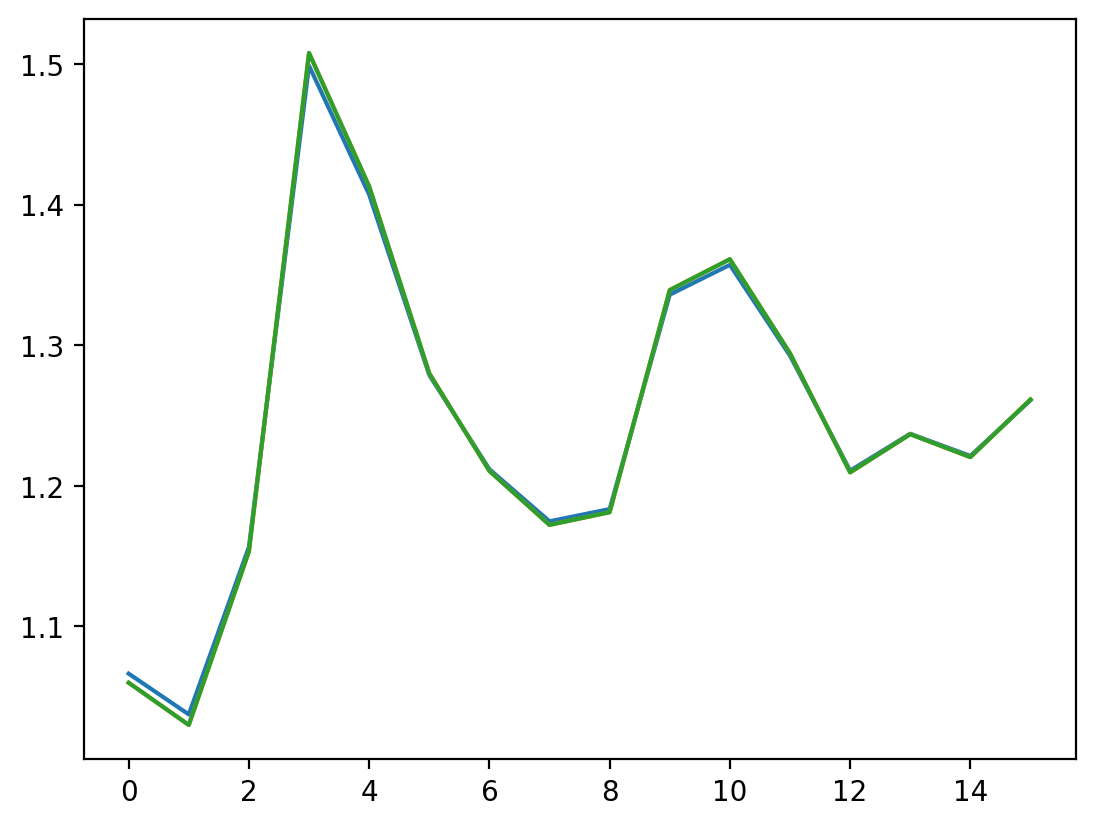

In [406]:
plt.plot(downsampled_bins.mean((1,2)))
plt.plot(length_normalized_target_sums.mean((1,2)))
plt.plot(g.values)

Text(0.5, 1.0, 'Data')

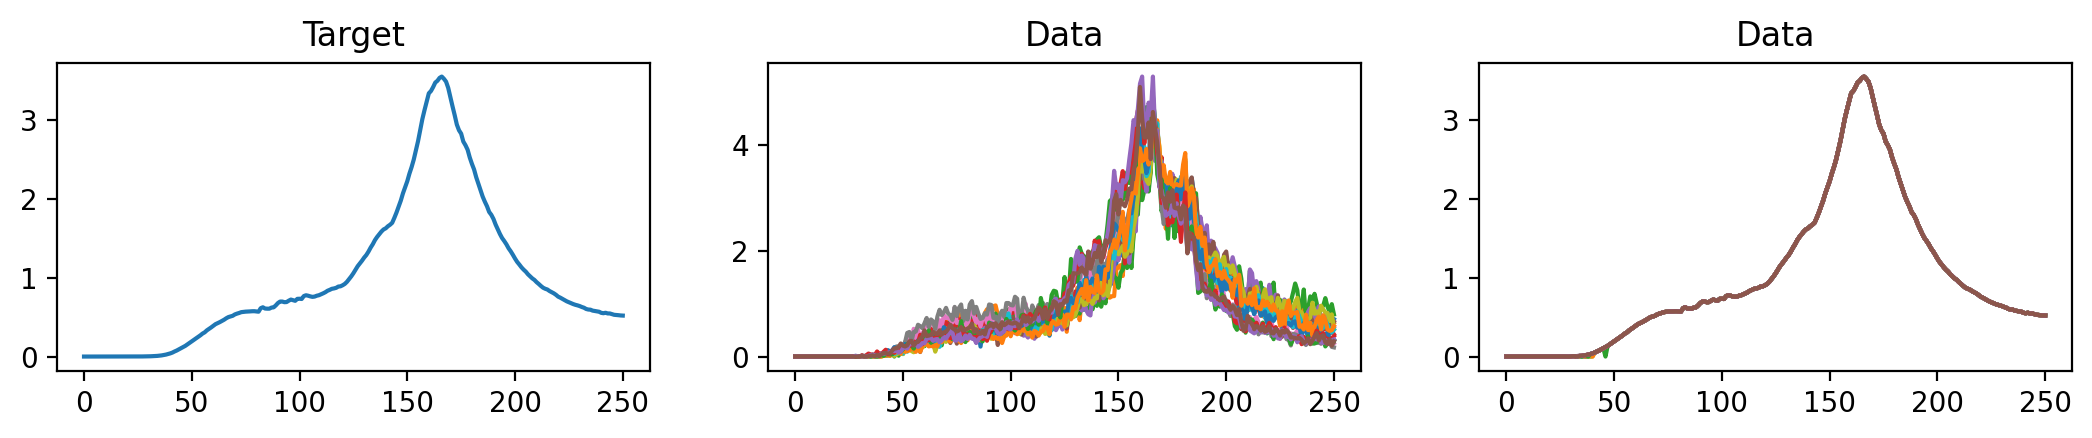

In [407]:
plt.figure(figsize=(13, 2))
plt.subplot(1, 3, 1)
plt.plot(target_distribution)
plt.title("Target")

plt.subplot(1, 3, 2)
plt.plot(normalized_1.mean(axis=2).T)
plt.title("Data")

plt.subplot(1, 3, 3)
plt.plot(length_normalized.mean(axis=2).T)
plt.title("Data")

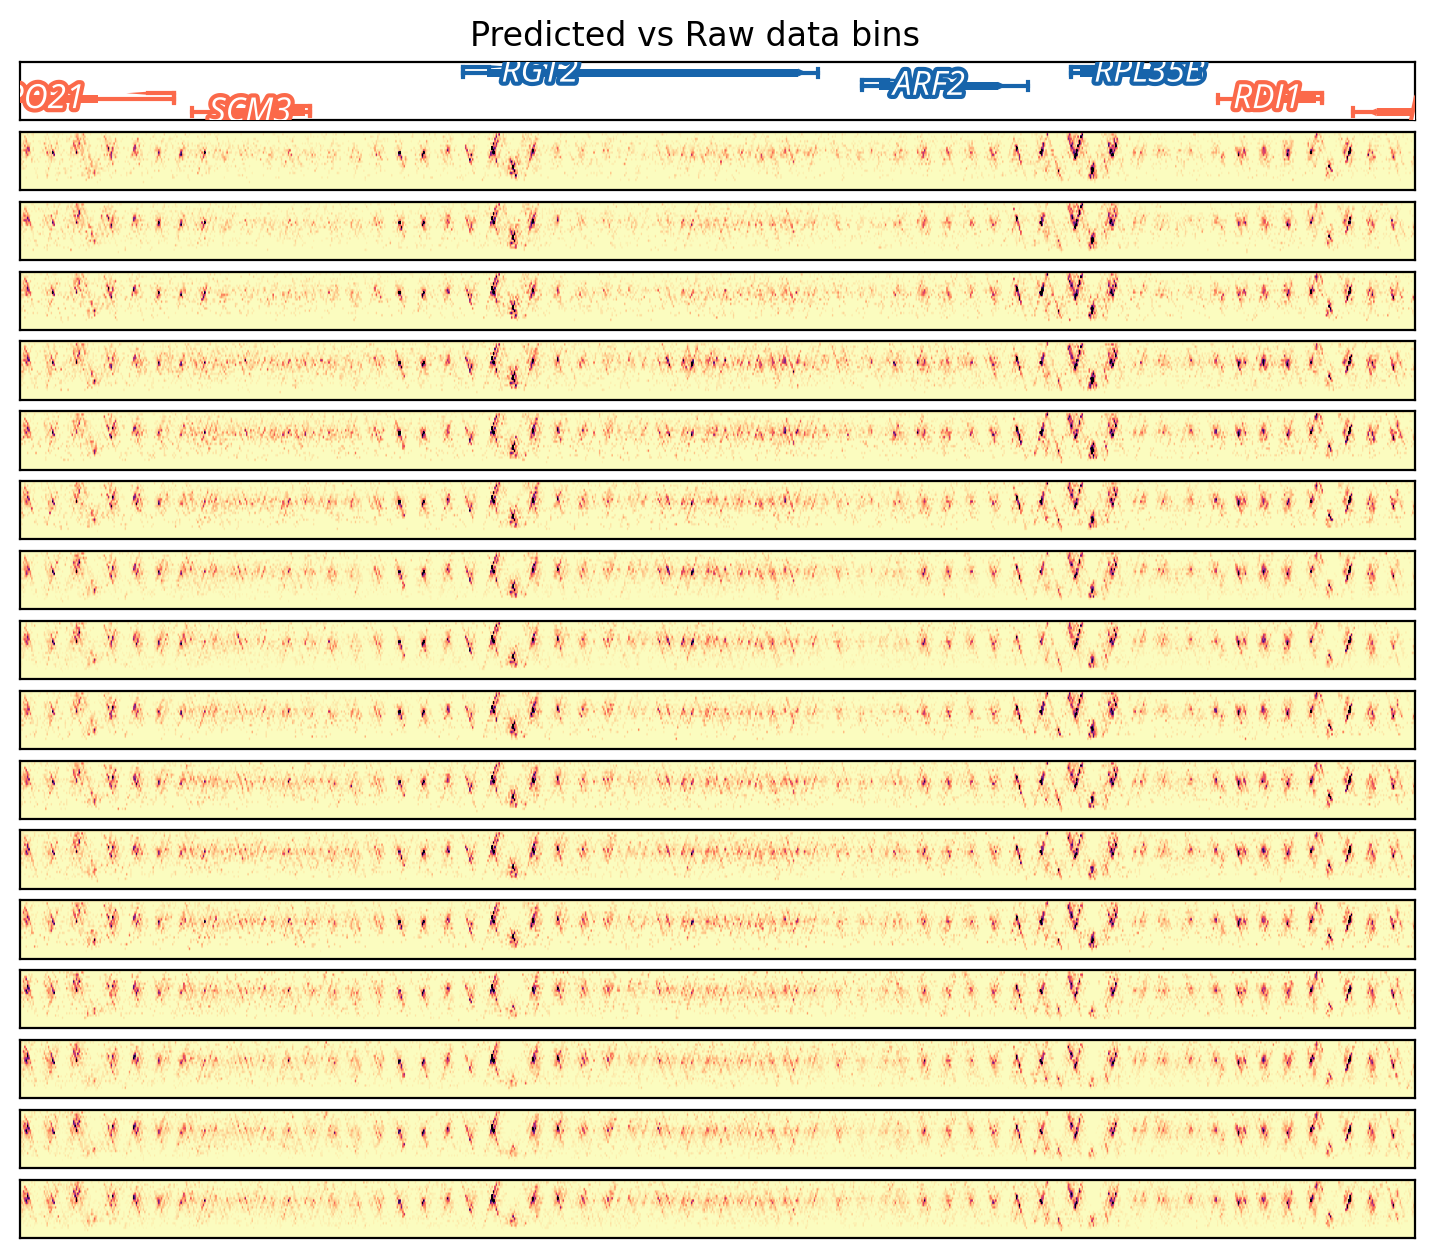

In [408]:
from src.chromatin_model import plot_raw_G

fig = plot_raw_G(downsampled_bins, config1, chrom, mnase_span, figsize=(9, 7),
          vmax=40)
